# Modelos Matematicos con ecuaciones en diferencias

------
------
#Modelo exponencial
------
------




El modelo discreto exponencial asume que el cambio en la cantidad entre dos pasos de tiempo consecutivos es proporcional a la cantidad en el paso de tiempo actual. Matemáticamente, un modelo discreto exponencial puede estar representado por la ecuación:


$$\boxed{P_{n+1}= k P_{n}}$$  

Donde:

   - $P_{n+1}$​ es la cantidad en el paso de tiempo $n+1$.
   - $P_{n}$ es la cantidad en el paso de tiempo siguiente.
   - $k$ es la tasa de crecimiento o decaimiento.


Este tipo de modelo tiene diversas aplicaciones en varias áreas:

    - Biología: Se puede utilizar para modelar el crecimiento de poblaciones de organismos en ambientes discretos.

    - Economía: Para modelar el crecimiento de inversiones, el aumento de la población laboral, entre otros.

    - Ingeniería: En sistemas de producción, como la producción de bienes en una cadena de montaje, o en la predicción de fallas en sistemas discretos.

    - Tecnología: Por ejemplo, en el modelado de la propagación de virus informáticos en redes discretas de computadoras.

    - Física: Para modelar la desintegración de partículas radiactivas o el decaimiento de una sustancia en un sistema cerrado.

----
##Generando datos modelo exponencial
----

In [6]:
import numpy as np

def Pn(n):

    #definimos el valor inicial
    Pn=[1]

    k = 1.8

    for i in range(n):

        Pn.append( Pn[i]* k    )

    return Pn

Pn_puntos = Pn(10)
n_puntos  = [i for i in range( len(Pn_puntos ) )]


----
## Datos de un modelo de crecimiento de levaduras
----

In [7]:
# Import pandas library
import pandas as pd


# Create the pandas DataFrame with column name is provided explicitly
df = pd.DataFrame( {  'Pn': Pn_puntos} )

# print dataframe.
df


,Pn
0,1.000000
1,1.800000
2,3.240000
3,5.832000
4,10.497600
5,18.895680
6,34.012224
7,61.222003
8,110.199606
9,198.359290


### Graficamos los datos

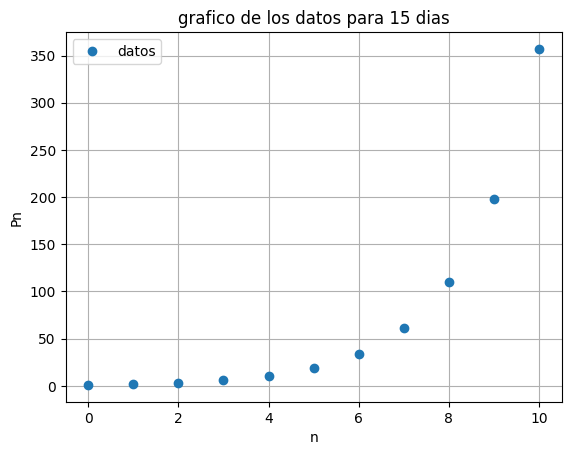

In [8]:
import matplotlib.pyplot as plt
plt.plot( n_puntos, Pn_puntos , 'o' , label='datos' )
plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()
plt.title('grafico de los datos para 15 dias')
plt.show()

### NOTA IMPORTANTE DE LOS PARAMETROS!

si queremos estimar la constante $k$, simplemente escalamos los datos usando un logaritmo $$y_n = \ln (P_n)$$

y luego aplicamos una regresion lineal!

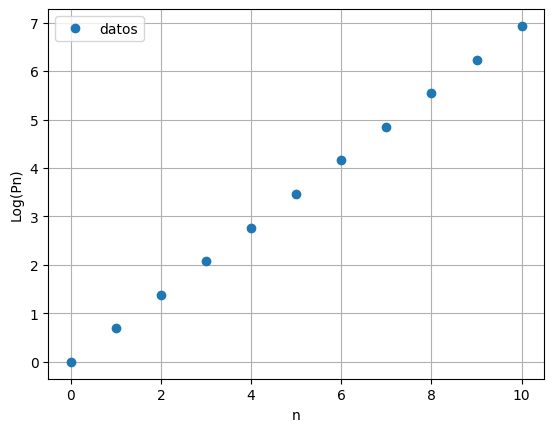

In [ ]:
plt.plot( n_puntos, np.log( Pn_puntos ), 'o' , label='datos' )
plt.xlabel('n')
plt.ylabel('Log(Pn)')
plt.legend()
plt.grid()
plt.show()

###Tomemos las primera diferencia!

$\Delta P_{n} = k P_{n}$ $\to$  $    P_{n+1} -  P_{n} = (k-1) P_{n}  $, de donde obtenemos

<br>

$$\Delta P_{n} = (k-1) P_{n} $$

<br>

Lo cual es una recta de $\Delta P_{n}$ contra $P_{n}$ con pendiente $(k-1)$.


In [ ]:
print("Pn_puntos =",Pn_puntos , "\n")


print("Pn_puntos[1:-1] =",Pn_puntos[1:], "\n")


print("Pn_puntos[0:-2] =",Pn_puntos[:-1], "\n")

Pn_puntos = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] 

Pn_puntos[1:-1] = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] 

Pn_puntos[0:-2] = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512] 



[  1   2   4   8  16  32  64 128 256 512]


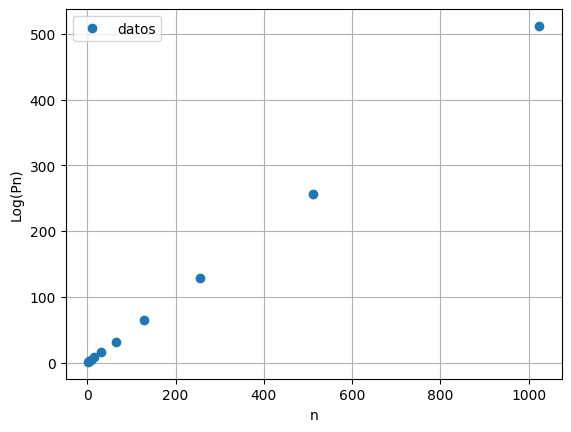

In [ ]:
DeltaPn= np.array(Pn_puntos[1:]) - np.array(Pn_puntos[:-1])

print(DeltaPn)

plt.plot( Pn_puntos[1:], DeltaPn , 'o' , label='datos' )
plt.xlabel('n')
plt.ylabel('delta(Pn)')
plt.legend()
plt.grid()


### Comportamiento asintotico?

Note que la ecuacion de diferencias para $\Delta P_{n}$ nunca puede ser cero si $k \neq 1$  y $P_{0} \neq 0$.

----
----
# Modelo logistico
----
----


Como se puede observar del ejemplo anterior, el modelo exponencial con $\kappa>1$ describe una población que crece ilimitadamente. Para tener un modelo un poco más realista del comportamiento de una población, se debe incluir un elemento que describa un factor que limite el crecimiento.

Según el [modelo logístico](https://en.wikipedia.org/wiki/Logistic_function#In_ecology:_modeling_population_growth), la tasa de crecimiento $\kappa$ se modifica para tener en cuenta un factor relacionado con la "capacidad de carga del medio", es decir, con la máxima población que se puede sostener con los recursos que tienen disponibles. En términos de una ecuación de diferencia, este modelo se expresa como

$$ P_{n+1} = \left(\kappa  - \beta\, P_n \right) P_{n}, $$

donde el término $-\beta\,P_n$ representa una disminución en la tasa de crecimiento a medida que la población aumenta, es decir, si la población es excesiva, los recursos escasean y se tiene menos descendencia. El termino $\beta/k$ se suele llamar la capacidad de carga.

$$ P_{n+1} =\kappa  P_{n} \left(1 - \dfrac{\beta}{\kappa} P_n \right) , $$



In [ ]:
import numpy as np

def Pn(n):

    #definimos el valor inicial
    Pn=[1]

    k   = 1.72

    beta= 0.1


    for i in range(n):

        Pn.append( Pn[i] * (k  - beta * Pn[i]) )

    return Pn

Pn_puntos = Pn(15)
n_puntos  = [i for i in range( len(Pn_puntos ) )]


In [ ]:
# Import pandas library
import pandas as pd


# Create the pandas DataFrame with column name is provided explicitly
df = pd.DataFrame( {  'Pn': Pn_puntos} )

df


,Pn
0,1.000000
1,1.620000
2,2.523960
3,3.704174
4,4.999089
5,6.099344
6,6.770672
7,7.061356
8,7.159257
9,7.188426


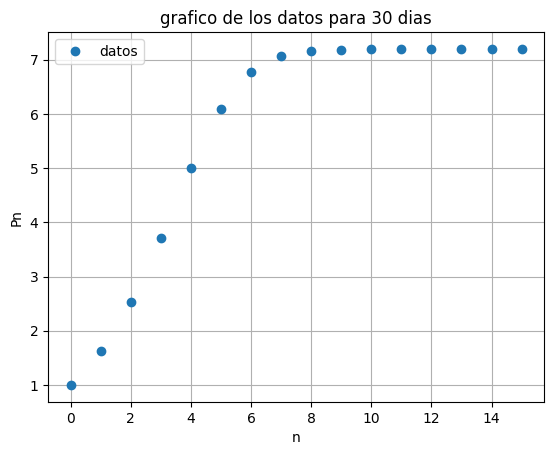

In [ ]:
import matplotlib.pyplot as plt
plt.plot( n_puntos, Pn_puntos , 'o' , label='datos' )
plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()
plt.title('grafico de los datos para 30 dias')
plt.show()

###NOTA IMPORTANTE DE LOS PARAMETROS

El modelo logistico no se le puede hacer escalamiento para encontrar los parametros $\kappa$ y $\beta$.

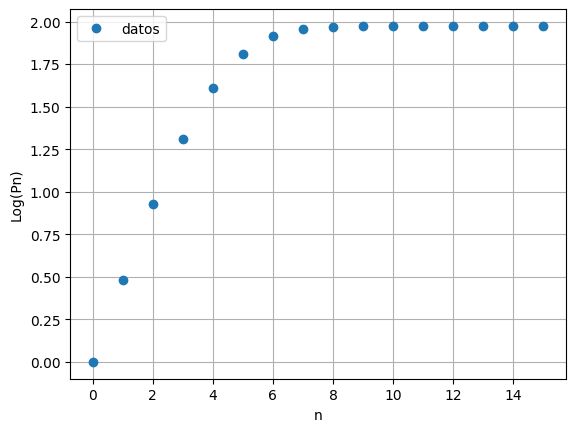

In [ ]:
plt.plot( n_puntos, np.log( Pn_puntos ), 'o' , label='datos' )
plt.xlabel('n')
plt.ylabel('Log(Pn)')
plt.legend()
plt.grid()
plt.show()

<ipython-input-16-f9aea9a1a0cc>:1: RuntimeWarning: divide by zero encountered in log
  plt.plot( np.log(n_puntos), np.log( Pn_puntos ), 'o' , label='datos' )


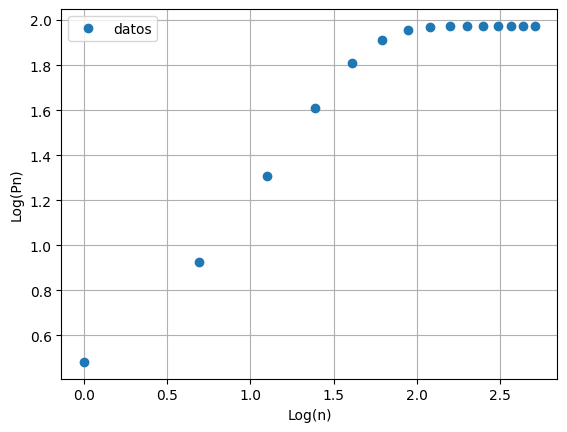

In [ ]:
plt.plot( np.log(n_puntos), np.log( Pn_puntos ), 'o' , label='datos' )
plt.xlabel('Log(n)')
plt.ylabel('Log(Pn)')
plt.legend()
plt.grid()
plt.show()

###**Como encontrar los parametros para un MODELO MATEMATICO logistico?**

Se puede demostrar que $P_{n+1} = \left(\kappa  - \beta\, P_n \right) P_{n}$ implica:

  $$
\dfrac{\Delta P_n}{P_n}  = - \beta P_n + (\kappa - 1), $$

Lo cual es una recta de $\dfrac{\Delta P_n}{P_n}$ contra $P_{n}$!!! Veamos esto con un grafico:

In [ ]:
#Veamos las listas y los indices!

print("Pn =",Pn , "\n")


print("Pn[1:-1] =",Pn[1:], "\n")


print("Pn[0:-2] =",Pn[:-1], "\n")

Pn = [1.         1.62       2.52396    3.70417379 4.99908857 6.09934369
 6.7706718  7.06135583 7.15925741 7.18842608 7.19674591 7.19908779
 7.1997445  7.19992845 7.19997997 7.19999439] 

Pn[1:-1] = [1.62       2.52396    3.70417379 4.99908857 6.09934369 6.7706718
 7.06135583 7.15925741 7.18842608 7.19674591 7.19908779 7.1997445
 7.19992845 7.19997997 7.19999439] 

Pn[0:-2] = [1.         1.62       2.52396    3.70417379 4.99908857 6.09934369
 6.7706718  7.06135583 7.15925741 7.18842608 7.19674591 7.19908779
 7.1997445  7.19992845 7.19997997] 



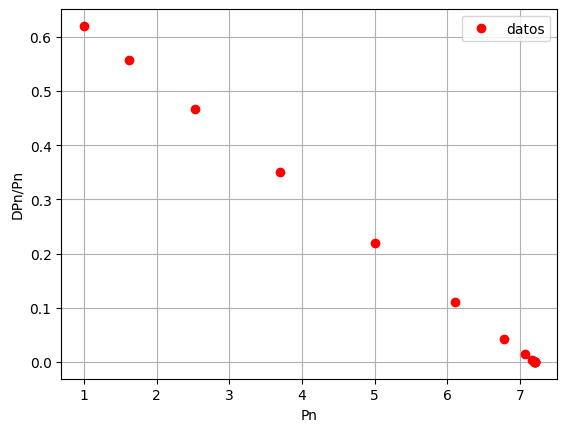

In [ ]:
#Pasamos la lista Pn a arraglo!
Pn= np.array(Pn_puntos)


#Definimos numericamente DPn
DPn = Pn[1:] - Pn[:-1]


#Definimos el cociente
DPnPn= DPn/Pn[:-1] #Ojo con el -2 en el arreglo, esto es para excluir el ultimo termino!


plt.plot( Pn[:-1] , DPnPn , 'ro' , label='datos' )
plt.xlabel('Pn')
plt.ylabel('DPn/Pn')
plt.legend()
plt.grid()
plt.show()

Este grafico quiere decir que

$$  \dfrac{\Delta P_n}{P_n} = - \beta P_n + (\kappa - 1) $$

Con lo que podemos hacer una regresion lineal para encontrar k y $\beta$.



In [ ]:
from scipy import stats   # Carga el módulo de herramientas estadísticas


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress(Pn[:-1] , DPnPn)

# Resultados del análisis
k    = regresion_lineal.intercept + 1  # Intercepto
beta = -1 * regresion_lineal.slope       # Pendiente


print("el valor de los parametros del modelo es  k= ", k, ', beta= ',beta)


el valor de los parametros del modelo es  k=  1.7199999999999998 , beta=  0.09999999999999996


### Comportamiento asintotico

Del grafico de $P_{n}$ contra $n$ observamos que claramente $P_{n}$ converge a un valor. Note que este valor se da si $$\Delta P_{n} = 0.$$ Por lo tanto la **ecuacion en diferencias** sucesion debera converger a:

<br>

$$ \boxed{P_{n} = \dfrac{\kappa - 1}{\beta}}$$

<br>

Veamos esto graficamente:

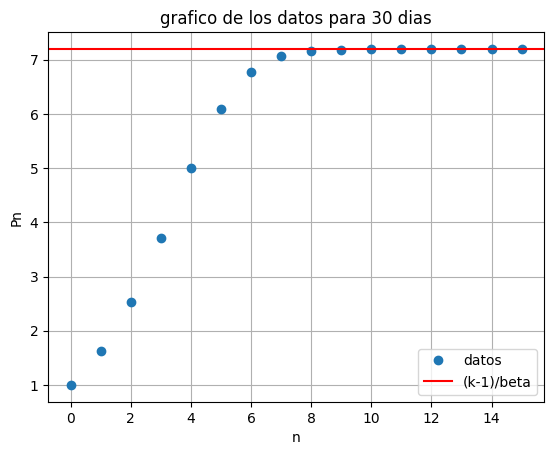

In [ ]:
import matplotlib.pyplot as plt
plt.plot( n_puntos, Pn_puntos , 'o' , label='datos' )


#trazar linea horizontal
plt.axhline(y=(k-1)/beta ,   color="r" , label="(k-1)/beta" )



plt.xlabel('n')
plt.ylabel('Pn')
plt.legend()
plt.grid()
plt.title('grafico de los datos para 30 dias')
plt.show()